<a href="https://colab.research.google.com/github/THEJoshinator20/ST554-HW/blob/main/554_HW6_McClure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#HW 6 - Class 554

by Joshua McClure

##Part I - More Practice Querying a Database

There is a database file on the assignment link called lahman_1871-2022.sqlite that is an sqlite database
downloaded from here. This database has information on Major League Baseball.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import sqlite3
from sqlite3 import Error
from numpy.random import default_rng
from sklearn import linear_model

1. Connect to the database and then look at all of the tables in the database (use read_sql() from
pandas to have this returned as a data frame).

In [ ]:
# Read in Lahman Dataset
data = pd.read_sql("SELECT * FROM sqlite_master WHERE type='table'", "sqlite:////content/lahman_1871-2022.sqlite")
data

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


2. Using SQL, construct a table of hall of fame pitchers (any hall of famer that pitched) that gives the
playerID and their total (sum) for GS, G, W, L, IPOuts, CG, SHO, and SV columns. The summing can
be done in pandas or in the SQL call.

In [ ]:
#Using SUM to get averages for the variables and creating an new variable name to account for it
#Using INNER JOIN to join the similar Hall of Fame and pitchers together
#Grouping by playerID to make sure it doesn't all sum together
hallpitch = pd.read_sql("SELECT DISTINCT P.playerID, SUM(P.GS) AS TotalGS, SUM(P.G) AS TotalG, SUM(P.W) AS TotalW, SUM(P.L) AS TotalL, SUM(P.IPOuts) AS TotalIPOuts, SUM(P.CG) AS TotalCG, SUM(P.SHO) AS TotalSHO, SUM(P.SV) AS TotalSV FROM Pitching AS P INNER JOIN HallOfFame AS HOF on P.playerID = HOF.playerID GROUP BY P.playerID", "sqlite:////content/lahman_1871-2022.sqlite")
hallpitch

print(hallpitch)


      playerID  TotalGS  TotalG  TotalW  TotalL  TotalIPOuts  TotalCG  \
0    abbotji01      254     263      87     108         5022       31   
1    adamsba01     5325    7230    2910    2100       134790     3090   
2    aguilri01       89     732      86      81         3874       10   
3     akerja01        0     495      47      45         2238        0   
4    alexado01      464     561     194     174        10103       98   
..         ...      ...     ...     ...     ...          ...      ...   
522  zachrpa01      154     293      69      67         3532       29   
523   zahnge01      270     304     111     109         5547       79   
524  zambrca01      302     354     132      91         5877       10   
525  zeileto01        0       2       0       0            6        0   
526   zitoba01      421     433     165     143         7730       12   

     TotalSHO  TotalSV  
0           6        0  
1         660      225  
2           0      318  
3           0      123 

3. For all of the hall of fame pitchers, use SQL to create a table of their batting statistics. Namely, the
playerID and their total (sum) for AB, R, H, HR, RBI, BB, and SO. The summing can be done in pandas
or in the SQL call.

In [ ]:
#Using SUM to get averages for the variables and creating an new variable name to account for it
#Using INNER JOIN to join the similar Hall of Fame and pitchers together
#Using INNER JOIN to join the similar Hall of Fame and pitchers together
#Grouping by playerID to make sure it doesn't all sum together
hallballpitch = pd.read_sql("""SELECT P.playerID, SUM(B.AB) AS TotalAB, SUM(B.R) AS TotalR, SUM(B.H) AS TotalH, SUM(B.HR) AS TotalHR, SUM(B.RBI) AS TotalRBI, SUM(B.BB) AS TotalBB, SUM(B.SO) AS TotalSO FROM Pitching AS P INNER JOIN Batting AS B ON P.playerID = B.playerID INNER JOIN HallOfFame AS HOF ON P.playerID = HOF.playerID GROUP BY P.playerID""", "sqlite:////content/lahman_1871-2022.sqlite")
print(hallballpitch)

      playerID  TotalAB  TotalR  TotalH  TotalHR  TotalRBI  TotalBB  TotalSO
0    abbotji01      231       0      22        0      33.0        0    110.0
1    adamsba01   290415   22515   61560      855   21375.0    15105  55290.0
2    aguilri01     2641     228     532       57     209.0      114    703.0
3     akerja01     1288      42      98        0      56.0       14    714.0
4    alexado01     6095     437    1012        0     391.0      207   1771.0
..         ...      ...     ...     ...      ...       ...      ...      ...
522  zachrpa01     3498      99     396        0      66.0      154   1408.0
523   zahnge01      602      42      84        0      14.0        0    126.0
524  zambrca01     8316     900    1980      288     852.0      120   2880.0
525  zeileto01    15146    1972    4008      506    2220.0     1890   2558.0
526   zitoba01     5160     180     525        0     165.0      270   1485.0

[527 rows x 8 columns]


4. Using pandas join the previous two tables together by pitcher. (If you want, try to do all of this via
SQL! Not required though, feel free to use pd.merge() if you’d like).

In [ ]:
#Using pd.merge to merge two previous tables together using playerID as the similar column
mergehpwhbp = pd.merge(hallpitch, hallballpitch, on = 'playerID')
mergehpwhbp

,playerID,TotalGS,TotalG,TotalW,TotalL,TotalIPOuts,TotalCG,TotalSHO,TotalSV,TotalAB,TotalR,TotalH,TotalHR,TotalRBI,TotalBB,TotalSO
0,abbotji01,254,263,87,108,5022,31,6,0,231,0,22,0,33.0,0,110.0
1,adamsba01,5325,7230,2910,2100,134790,3090,660,225,290415,22515,61560,855,21375.0,15105,55290.0
2,aguilri01,89,732,86,81,3874,10,0,318,2641,228,532,57,209.0,114,703.0
3,akerja01,0,495,47,45,2238,0,0,123,1288,42,98,0,56.0,14,714.0
4,alexado01,464,561,194,174,10103,98,18,3,6095,437,1012,0,391.0,207,1771.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522,zachrpa01,154,293,69,67,3532,29,7,3,3498,99,396,0,66.0,154,1408.0
523,zahnge01,270,304,111,109,5547,79,20,1,602,42,84,0,14.0,0,126.0
524,zambrca01,302,354,132,91,5877,10,5,0,8316,900,1980,288,852.0,120,2880.0
525,zeileto01,0,2,0,0,6,0,0,0,15146,1972,4008,506,2220.0,1890,2558.0


##Part II - Messing with Classes

5. In the previous homework we used a loop to repeatedly do simulations around the estimate of a sample
slope. The setup was:
* Recall we assume the following model for SLR:

                    Yi = β0 + β1xi + Ei

    * where the Ei are assumed to be indendent and identically distributed from a Normal distribution with mean 0 and variance σ^2. Let’s assume σ^2 = 1 for simplicity.
    
    * We can generate data from this model by assuming values for β0, β1, and n, along with a sequence of x values.

### Base Code to replicate with Class

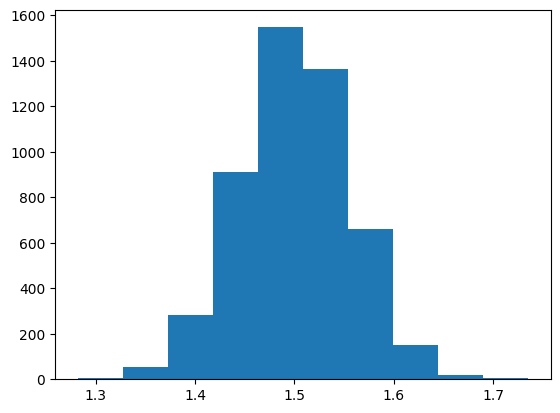

np.float64(0.0038)

In [ ]:
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5

# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = len(x)

#prepare for the LR fit
reg = linear_model.LinearRegression()

#Create a reg object
#initialize array to save estimates (we don't need beta0 but I'm keeping it!)
beta_array = np.zeros(shape = (5000, 2))

for i in range(5000):
    #create the 'responses' modeled from the line plus a random deviation
    y = beta_0 + beta_1*x + rng.standard_normal(n)
    #find the least squares solutions and store them
    fit = reg.fit(x.reshape(-1, 1), y)
    beta_array[i, :] = [fit.intercept_, fit.coef_[0]]

#visualize the distribution of the slopedata
plt.hist(beta_array[:, 1])
plt.show()

#estimate the probability we are larger than 1.65
bool_prob = beta_array[:, 1] > 1.65
bool_prob.mean()

##Class Code

In [ ]:
class SLR_slope_simulator:

  #Stores beta_0, beta_1, x, sigma, and seed as instance arguments and slope as
  #a empty list that will be added to later

  def __init__(self, beta_0, beta_1, x, sigma, seed):
    self.beta_0 = beta_0
    self.beta_1 = beta_1
    self.sigma = sigma
    self.seed = seed
    self.rng = default_rng(seed)
    self.x = x
    self.n = len(x)
    self.slopes = []

  def generate_data(self):

    #Producing y based off attributes made in __init__ def and keeping x and y
    #for further uses

    y = self.beta_0 + self.beta_1 * self.x + self.rng.standard_normal(self.n) * self.sigma
    return self.x, y

  def fit_slope(self, x_data, y_data):
    #Producing fuction to get the estimated slope, stores the slope value produced
    reg = linear_model.LinearRegression()
    fit = reg.fit(x_data.reshape(-1, 1), y_data)
    return fit.coef_[0]

  def run_simulations(self, simulations):
    #Produce data for X and Y, get the stimated slope and add it to empty list
    #Make slope list into sn array for use in producing plot
    self.slopes = [] # Clear slopes from previous runs if any
    for i in range(simulations):
      x_sim, y_sim = self.generate_data()
      estimated_slope = self.fit_slope(x_sim, y_sim)
      self.slopes.append(estimated_slope)
    self.slopes = np.array(self.slopes)

  def plot_sampling_distribution(self):
    #If and else statement to make sure slope data was produced
    #Makes the plot for the slope with thethe labels and title
    if not isinstance(self.slopes, np.ndarray) or self.slopes.size == 0:
      print("run_simulations() must be called first")
    else:
      plt.hist(self.slopes)
      plt.title("Sampling Distribution of the Slope Estimator")
      plt.xlabel("Estimated Slope")
      plt.ylabel("Frequency")
      plt.show()

  def find_prob(self, value, sided="above"):
    #If and else statement to make sure slope data was produced
    #
    if not isinstance(self.slopes, np.ndarray) or self.slopes.size == 0:
      print("run_simulations() must be called first")
      return None
    else:
      if sided == "above":
        bool_prob = self.slopes > value
      elif sided == "below":
        bool_prob = self.slopes < value
      elif sided == "two-sided":
        bool_prob = (self.slopes > value) | (self.slopes < -value)
      else:
        print("Invalid 'sided' argument. Use 'above', 'below', or 'two-sided'.")
        return None
      return bool_prob.mean()

– Creates an instance of the object with beta_0 = 12, beta_1 = 2, x = np.array(list(np.linspace(start
= 0, stop = 10, num = 11))*3), sigma = 1, and seed = 10

– Call your run_simulation() method (this should return the error message)

– Run 10000 simulations

– Plot the sampling distribution

– Approximate the two-sided probability of being larger than 2.1

– Print out the value of the simulated slopes using the attribute

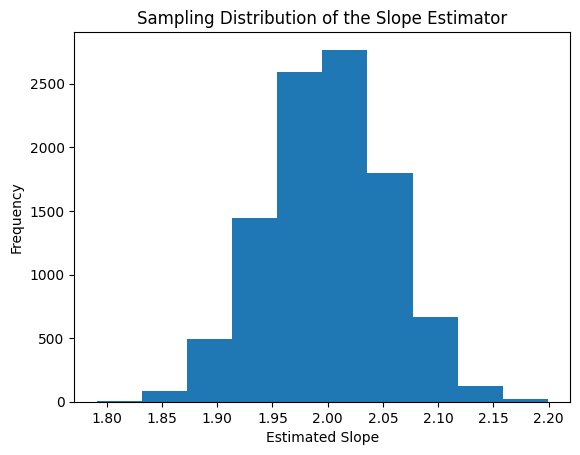

Approximate two-sided probability of being larger than 2.1: 0.0352
Simulated slopes (first 10 values): [2.0239168  1.99560551 2.04249093 1.96489641 2.01114235 1.98626121
 2.03443803 2.08981268 2.01691868 1.91179937]
Total number of simulated slopes: 10000


In [ ]:
#Set the init values to what was specified
beta_0 = 12
beta_1 = 2
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
sigma = 1
seed = 10

# Create an instance of the SLR_slope_simulator class
simulator = SLR_slope_simulator(beta_0, beta_1, x, sigma, seed)

# Call run_simulations method
simulator.run_simulations(10000)

# Plot the sampling distribution
simulator.plot_sampling_distribution()

# Approximate the two-sided probability of being larger than 2.1
prob_two_sided = simulator.find_prob(2.1, sided="two-sided")
print(f"Approximate two-sided probability of being larger than 2.1: {prob_two_sided}")

# Print out the value of the simulated slopes
print("Simulated slopes (first 10 values):", simulator.slopes[:10])
print("Total number of simulated slopes:", len(simulator.slopes))